# Detector Espectral Puro: Primalidade de um Único Inteiro

**T. Bandeira · Junho de 2026**

Versão refinada do detector R(k). Em vez de calcular a diferença entre dois intervalos Q(p+k) e Q(p), testamos diretamente o sinal de um único inteiro $m$:

$$S_m(t) = \log\left|\frac{1}{1 - m^{-1/2-it}}\right| = -\frac{1}{2}\log\left(1 - 2m^{-1/2}\cos(t\log m) + m^{-1}\right)$$

**Hipótese refinada:** a estrutura de $S_m(t)$ no contexto dos primos já conhecidos $< m$ distingue primos de compostos. Especificamente:

- Se $m$ é primo: $S_m$ introduz uma frequência $f_m = \log(m)/(2\pi)$ irredutível aos primos anteriores
- Se $m$ é composto $m = a \cdot b$: $S_m$ é aproximadamente uma combinação dos sinais $S_a$ e $S_b$ já conhecidos

**Questão central:** existe uma assinatura espectral mensurável que distingue os dois casos sem oráculo externo?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import pearsonr
from sympy import isprime, primerange, factorint
import math, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
print('Dependências carregadas ✓')

Dependências carregadas ✓


## 1. Sinal de um único inteiro e métricas

In [2]:
def S_m(m, t_vals):
    """Sinal espectral de um único inteiro m em s=1/2+it."""
    lm   = math.log(m)
    a    = math.exp(-0.5 * lm)
    term = np.maximum(1 - 2*a*np.cos(t_vals*lm) + a*a, 1e-300)
    return -0.5 * np.log(term)

def espectro(sinal, t_step, f_min=0.05, f_max=0.9):
    """FFT do sinal, retorna (freq, amplitude normalizada)."""
    s    = sinal - np.mean(sinal)
    fft  = np.fft.rfft(s)
    freq = np.fft.rfftfreq(len(s), d=t_step)
    amp  = np.abs(fft)
    mask = (freq > f_min) & (freq < f_max)
    return freq[mask], amp[mask]

def reconstrucao_composto(m, t_vals):
    """
    Para m composto, tenta reconstruir S_m como combinação linear
    dos sinais dos seus fatores primos.
    Retorna: sinal reconstruído, coeficientes, erro de reconstrução.
    """
    fatores = list(factorint(m).keys())  # fatores primos únicos
    if not fatores:
        return None, [], float('inf')

    # Sinais dos fatores
    sinais_fat = np.array([S_m(f, t_vals) for f in fatores])

    # Regressão linear: S_m ≈ sum_i c_i * S_{f_i}
    A   = sinais_fat.T
    s_m = S_m(m, t_vals)
    try:
        coefs, _, _, _ = np.linalg.lstsq(A, s_m, rcond=None)
    except:
        return None, [], float('inf')

    reconstruido = A @ coefs
    erro         = np.mean((s_m - reconstruido)**2) / (np.mean(s_m**2) + 1e-10)
    return reconstruido, coefs, erro

def correlacao_com_fatores(m, t_vals, primos_conhecidos):
    """
    Correlação de S_m com cada primo conhecido < m.
    Um composto deve ter alta correlação com seus fatores.
    Um primo deve ter baixa correlação com todos.
    """
    sm   = S_m(m, t_vals)
    cors = {}
    for q in primos_conhecidos:
        if q >= m:
            break
        sq       = S_m(q, t_vals)
        r, _     = pearsonr(sm, sq)
        cors[q]  = r
    return cors

print('Funções definidas ✓')

Funções definidas ✓


## 2. Visualização: S_m para primos e compostos

Comparação visual do sinal e espectro de inteiros primo vs. composto de mesma faixa.

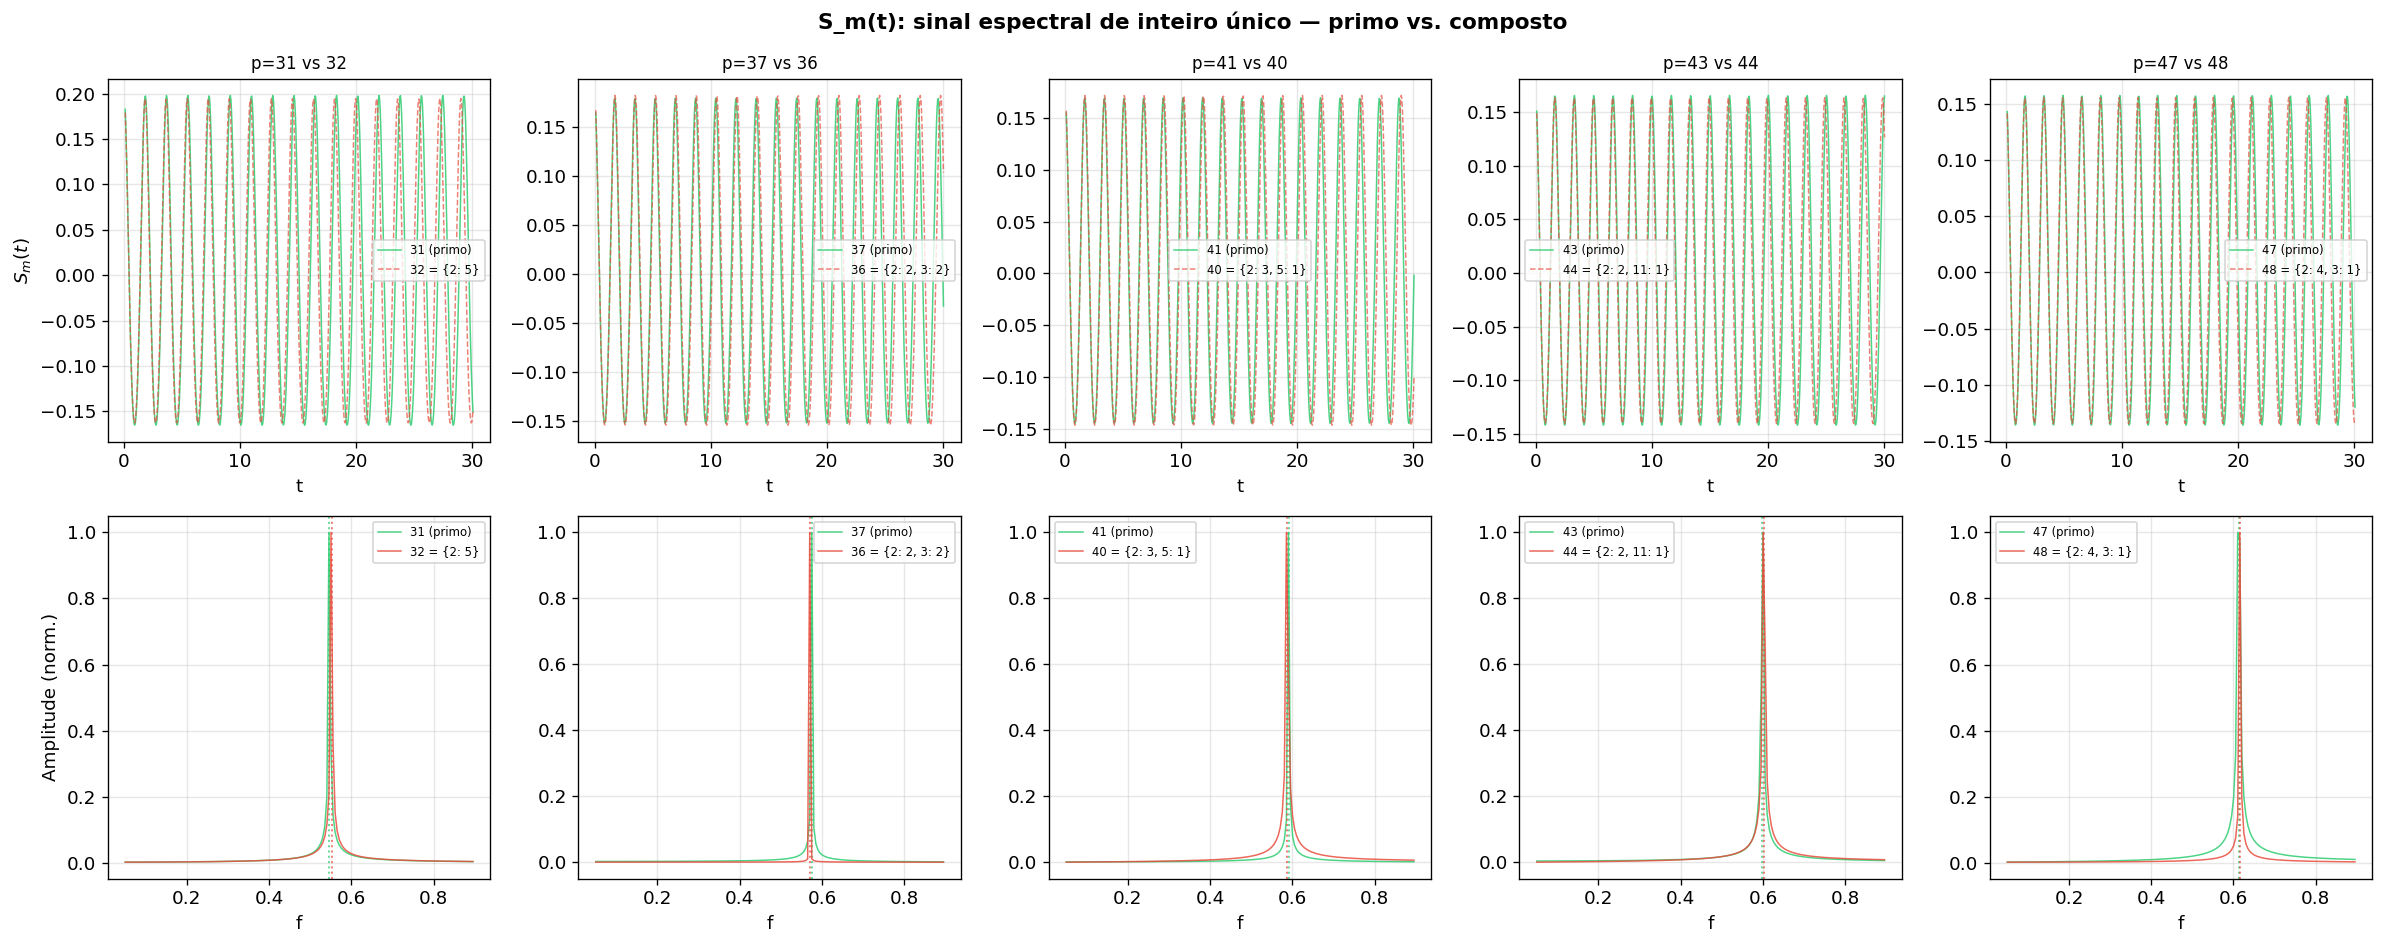

Figura salva ✓


In [3]:
T_MAX  = 200
T_STEP = 0.05
t_vals = np.arange(0.1, T_MAX, T_STEP)

# Pares primo/composto próximos para comparação
pares = [
    (31, 32),   # primo vs 2^5
    (37, 36),   # primo vs 6^2
    (41, 40),   # primo vs 2^3 × 5
    (43, 44),   # primo vs 4 × 11
    (47, 48),   # primo vs 2^4 × 3
]

fig, axes = plt.subplots(2, len(pares), figsize=(4*len(pares), 8))
fig.suptitle('S_m(t): sinal espectral de inteiro único — primo vs. composto', fontsize=13, fontweight='bold')

for col, (p, c) in enumerate(pares):
    fats_c = factorint(c)

    for m, cor, label in [(p, '#2ecc71', f'{p} (primo)'), (c, '#e74c3c', f'{c} = {fats_c}')]:
        sm          = S_m(m, t_vals)
        freq, amp   = espectro(sm, T_STEP)
        f_m         = math.log(m) / (2*math.pi)

        # Painel superior: sinal
        ax = axes[0, col]
        if m == p:
            ax.plot(t_vals[:600], sm[:600], color=cor, lw=0.9, label=label, alpha=0.85)
        else:
            ax.plot(t_vals[:600], sm[:600], color=cor, lw=0.9, label=label, alpha=0.7, ls='--')
        ax.set_title(f'p={p} vs {c}', fontsize=10)
        ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel('$S_m(t)$')
        ax.set_xlabel('t')

        # Painel inferior: espectro
        ax2 = axes[1, col]
        amp_n = amp / amp.max() if amp.max() > 0 else amp
        ax2.plot(freq, amp_n, color=cor, lw=0.9, label=label, alpha=0.85)
        ax2.axvline(f_m, color=cor, lw=1.2, ls=':', alpha=0.7)
        if col == 0:
            ax2.set_ylabel('Amplitude (norm.)')
        ax2.set_xlabel('f')
        ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('Sm_primo_vs_composto.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 3. Teste de reconstrução: S_m ≈ combinação dos fatores?

Para compostos, verificamos se $S_m$ é bem aproximado por combinação linear dos $S_{f_i}$. Para primos, o erro de reconstrução deveria ser alto (irredutível).

In [4]:
# Candidatos: primos e compostos na faixa [20, 70]
candidatos = list(range(20, 71))
primos_ref = list(primerange(2, 20))  # primos conhecidos usados como base

print('=== ERRO DE RECONSTRUÇÃO: S_m ≈ combinação dos fatores primos ===')
print()
print(f'  {"m":>4} | {"primo?":>7} | {"fatores":>15} | {"erro_rec":>10} | {"coefs"}')
print('-' * 75)

erros_primos   = []
erros_compostos = []
dados_rec      = []

for m in candidatos:
    eh_primo = isprime(m)

    if eh_primo:
        # Para primos: usar todos os primos menores como "fatores" tentados
        fatores_tentados = [q for q in primos_ref if q < m]
        # Reconstrução tentada com primos menores
        sinais_fat = np.array([S_m(f, t_vals) for f in fatores_tentados])
        sm         = S_m(m, t_vals)
        A          = sinais_fat.T
        try:
            coefs, _, _, _ = np.linalg.lstsq(A, sm, rcond=None)
            rec   = A @ coefs
            erro  = np.mean((sm - rec)**2) / (np.mean(sm**2) + 1e-10)
        except:
            erro, coefs = float('inf'), []
        fatores_str = 'primo'
        erros_primos.append(erro)
    else:
        rec, coefs, erro = reconstrucao_composto(m, t_vals)
        fats        = factorint(m)
        fatores_str = '×'.join(f'{f}^{e}' if e > 1 else str(f) for f, e in fats.items())
        erros_compostos.append(erro)

    coefs_str = ', '.join(f'{c:.2f}' for c in (coefs[:3] if len(coefs) > 0 else []))
    marcador  = '★' if eh_primo else ''
    print(f'  {m:>4} | {str(eh_primo):>7} | {fatores_str:>15} | {erro:>10.4f} | [{coefs_str}] {marcador}')

    dados_rec.append({'m': m, 'primo': eh_primo, 'erro': erro})

print()
print(f'  Erro médio — PRIMOS   : {np.mean(erros_primos):.4f}  (±{np.std(erros_primos):.4f})')
print(f'  Erro médio — COMPOSTOS: {np.mean(erros_compostos):.4f}  (±{np.std(erros_compostos):.4f})')

=== ERRO DE RECONSTRUÇÃO: S_m ≈ combinação dos fatores primos ===

     m |  primo? |         fatores |   erro_rec | coefs
---------------------------------------------------------------------------
    20 |   False |           2^2×5 |     1.0000 | [0.00, 0.00] 
    21 |   False |             3×7 |     1.0000 | [-0.00, -0.00] 
    22 |   False |            2×11 |     1.0000 | [0.00, 0.00] 
    23 |    True |           primo |     0.9994 | [-0.00, -0.00, -0.01] ★
    24 |   False |           2^3×3 |     1.0000 | [0.00, -0.00] 
    25 |   False |             5^2 |     0.9516 | [0.10] 
    26 |   False |            2×13 |     1.0000 | [-0.00, 0.00] 
    27 |   False |             3^3 |     0.9894 | [0.03] 
    28 |   False |           2^2×7 |     1.0000 | [0.00, -0.00] 
    29 |    True |           primo |     0.9998 | [0.00, 0.00, -0.00] ★
    30 |   False |           2×3×5 |     0.9999 | [0.00, 0.00, -0.00] 
    31 |    True |           primo |     0.9999 | [0.00, 0.00, -0.00] ★
    32 

## 4. Distribuição dos erros: separabilidade primo vs. composto

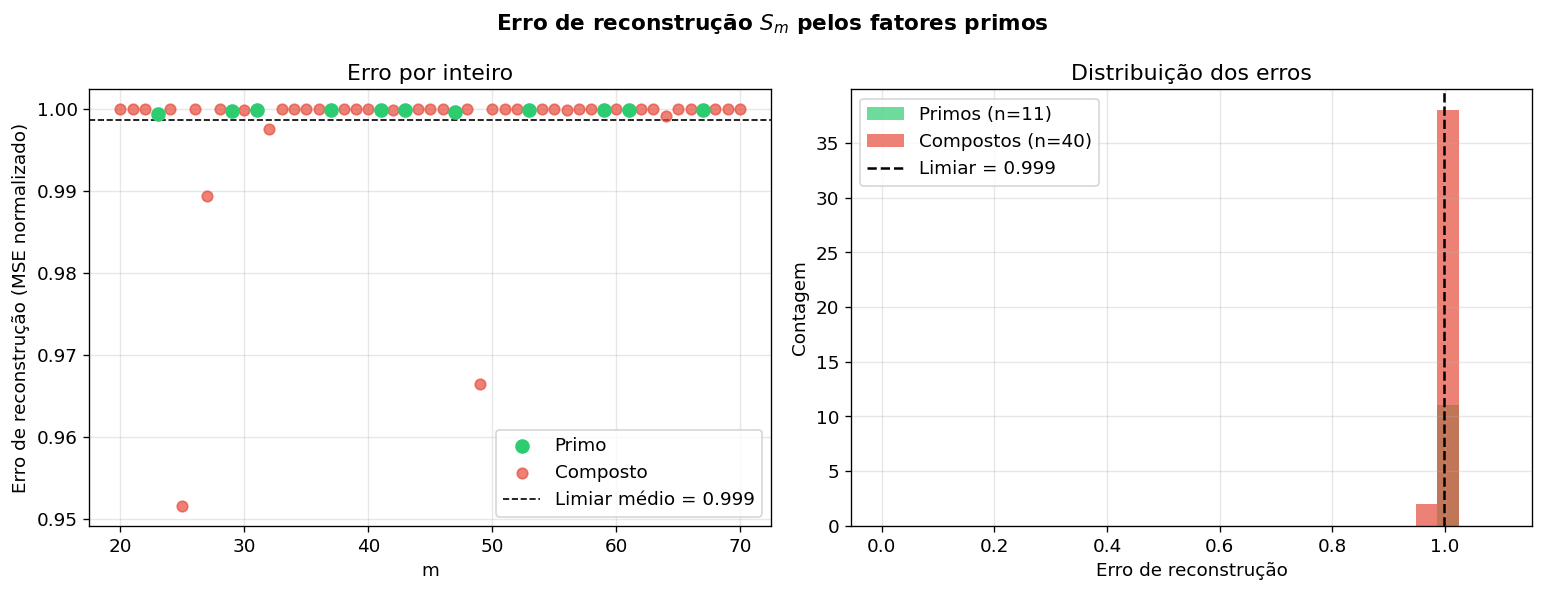

Figura salva ✓


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Erro de reconstrução $S_m$ pelos fatores primos', fontsize=13, fontweight='bold')

ms_p  = [d['m']    for d in dados_rec if d['primo']]
ep    = [d['erro'] for d in dados_rec if d['primo']]
ms_c  = [d['m']    for d in dados_rec if not d['primo']]
ec    = [d['erro'] for d in dados_rec if not d['primo']]

# Painel 1: erro por m
ax = axes[0]
ax.scatter(ms_p, ep, color='#2ecc71', s=60, label='Primo', zorder=5)
ax.scatter(ms_c, ec, color='#e74c3c', s=40, label='Composto', alpha=0.7, zorder=4)
# Limiar ótimo
todos_erros = ep + ec
limiar = (np.mean(ep) + np.mean(ec)) / 2
ax.axhline(limiar, color='black', ls='--', lw=1, label=f'Limiar médio = {limiar:.3f}')
ax.set_xlabel('m')
ax.set_ylabel('Erro de reconstrução (MSE normalizado)')
ax.set_title('Erro por inteiro')
ax.legend()

# Painel 2: histograma
ax2 = axes[1]
bins = np.linspace(0, max(todos_erros)*1.1, 30)
ax2.hist(ep, bins=bins, color='#2ecc71', alpha=0.7, label=f'Primos (n={len(ep)})')
ax2.hist(ec, bins=bins, color='#e74c3c', alpha=0.7, label=f'Compostos (n={len(ec)})')
ax2.axvline(limiar, color='black', ls='--', lw=1.5, label=f'Limiar = {limiar:.3f}')
ax2.set_xlabel('Erro de reconstrução')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição dos erros')
ax2.legend()

plt.tight_layout()
plt.savefig('distribuicao_erros.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 5. Critério de detecção via erro de reconstrução

Usando o limiar médio entre as duas distribuições como separador.

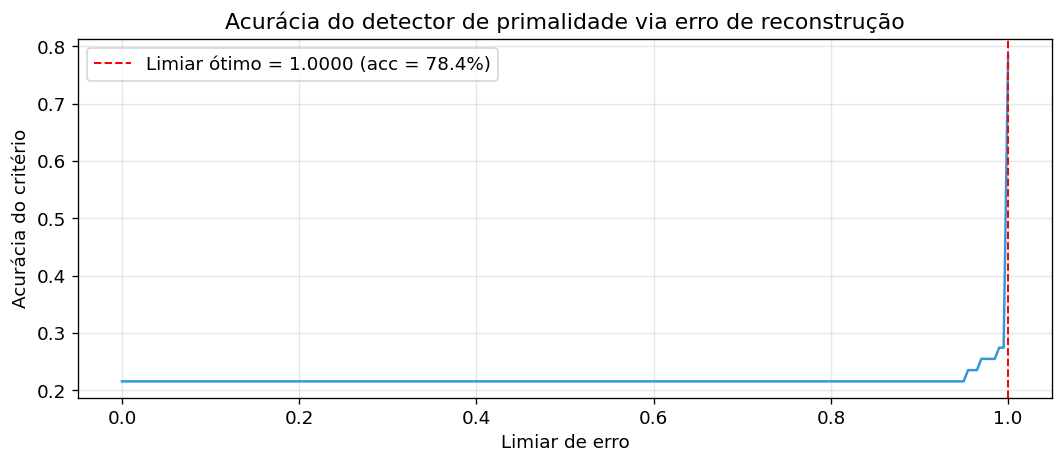

Limiar ótimo: 1.0000
Acurácia máxima: 78.4%

     m |  primo? |     erro |   predição |  correto?
-------------------------------------------------------
    20 |   False |   1.0000 |      False |         ✓
    21 |   False |   1.0000 |      False |         ✓
    22 |   False |   1.0000 |      False |         ✓
    23 |    True |   0.9994 |      False |         ✗
    24 |   False |   1.0000 |      False |         ✓
    25 |   False |   0.9516 |      False |         ✓
    26 |   False |   1.0000 |      False |         ✓
    27 |   False |   0.9894 |      False |         ✓
    28 |   False |   1.0000 |      False |         ✓
    29 |    True |   0.9998 |      False |         ✗
    30 |   False |   0.9999 |      False |         ✓
    31 |    True |   0.9999 |      False |         ✗
    32 |   False |   0.9976 |      False |         ✓
    33 |   False |   1.0000 |      False |         ✓
    34 |   False |   1.0000 |      False |         ✓
    35 |   False |   1.0000 |      False |         

In [6]:
# Varrer limiares e medir acurácia
limiares = np.linspace(0, max(todos_erros), 200)
acuracias = []

for thr in limiares:
    corretos = sum(
        1 for d in dados_rec
        if (d['erro'] > thr) == d['primo']
    )
    acuracias.append(corretos / len(dados_rec))

melhor_thr = limiares[np.argmax(acuracias)]
melhor_acc = max(acuracias)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(limiares, acuracias, color='#3498db', lw=1.5)
ax.axvline(melhor_thr, color='red', ls='--', lw=1.2,
           label=f'Limiar ótimo = {melhor_thr:.4f} (acc = {melhor_acc:.1%})')
ax.set_xlabel('Limiar de erro')
ax.set_ylabel('Acurácia do critério')
ax.set_title('Acurácia do detector de primalidade via erro de reconstrução')
ax.legend()
plt.tight_layout()
plt.savefig('acuracia_limiar.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Limiar ótimo: {melhor_thr:.4f}')
print(f'Acurácia máxima: {melhor_acc:.1%}')

# Tabela de predições com limiar ótimo
print(f'\n  {"m":>4} | {"primo?":>7} | {"erro":>8} | {"predição":>10} | {"correto?":>9}')
print('-' * 55)
for d in dados_rec:
    pred    = d['erro'] > melhor_thr
    correto = pred == d['primo']
    print(f'  {d["m"]:>4} | {str(d["primo"]):>7} | {d["erro"]:>8.4f} | '
          f'{str(pred):>10} | {"✓" if correto else "✗":>9}')

## 6. Correlação de S_m com os primos conhecidos

Métrica alternativa: correlação de Pearson entre $S_m$ e cada $S_q$ para $q$ primo conhecido. Compostos devem ter alta correlação com seus fatores.

In [7]:
CANDIDATOS_COR = [30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49]
primos_base    = list(primerange(2, 30))

print('=== CORRELAÇÃO DE S_m COM PRIMOS CONHECIDOS < 30 ===')
print()

# Cabeçalho
header = f'  {"m":>4} | {"primo?":>7} | ' + ' | '.join(f'{q:>5}' for q in primos_base)
print(header)
print('-' * len(header))

cor_data = []
for m in CANDIDATOS_COR:
    cors    = correlacao_com_fatores(m, t_vals, primos_base)
    eh_p    = isprime(m)
    cors_v  = [cors.get(q, 0) for q in primos_base]
    max_cor = max(cors_v)
    q_max   = primos_base[np.argmax(cors_v)]

    row = f'  {m:>4} | {str(eh_p):>7} | ' + ' | '.join(f'{v:>5.2f}' for v in cors_v)
    print(row)
    cor_data.append({'m': m, 'primo': eh_p, 'cors': cors_v, 'max_cor': max_cor, 'q_max': q_max})

print()
print('Correlação máxima com algum primo conhecido:')
print(f'  PRIMOS   — média: {np.mean([d["max_cor"] for d in cor_data if d["primo"]]):.3f}')
print(f'  COMPOSTOS — média: {np.mean([d["max_cor"] for d in cor_data if not d["primo"]]):.3f}')

=== CORRELAÇÃO DE S_m COM PRIMOS CONHECIDOS < 30 ===

     m |  primo? |     2 |     3 |     5 |     7 |    11 |    13 |    17 |    19 |    23 |    29
------------------------------------------------------------------------------------------------
    30 |   False |  0.00 |  0.01 | -0.01 |  0.00 | -0.00 | -0.01 |  0.00 | -0.00 |  0.00 |  0.07
    31 |    True |  0.00 |  0.00 | -0.00 |  0.00 | -0.00 | -0.01 |  0.01 | -0.01 | -0.00 |  0.05
    32 |   False |  0.05 |  0.00 | -0.00 |  0.00 | -0.00 | -0.01 |  0.01 | -0.01 | -0.00 |  0.04
    33 |   False |  0.00 |  0.00 | -0.00 |  0.00 | -0.00 | -0.01 |  0.00 | -0.00 |  0.00 |  0.02
    35 |   False | -0.00 |  0.00 | -0.00 | -0.00 | -0.00 | -0.00 | -0.00 |  0.00 |  0.01 | -0.00
    36 |   False | -0.00 |  0.00 | -0.00 | -0.00 | -0.01 |  0.00 | -0.00 |  0.01 |  0.01 | -0.02
    37 |    True | -0.01 | -0.00 | -0.00 | -0.00 | -0.00 |  0.00 | -0.01 |  0.01 |  0.01 | -0.02
    38 |   False | -0.00 | -0.01 |  0.00 | -0.00 |  0.00 |  0.00 | -0.00 

## 7. Efeito de t_max na qualidade da separação

=== ERRO DE RECONSTRUÇÃO vs. t_max ===

   t_max |    acc |      sep | erro_p_med | erro_c_med
-------------------------------------------------------
      30 |  20.0% |  -0.2468 |     0.7525 |     0.9993
      50 |  20.0% |  -0.0523 |     0.9472 |     0.9995
      75 |  10.0% |  -0.0183 |     0.9813 |     0.9996
     100 |  30.0% |  -0.0145 |     0.9850 |     0.9994
     150 |  20.0% |  -0.0045 |     0.9951 |     0.9995
     200 |  30.0% |  -0.0018 |     0.9977 |     0.9995
     300 |  30.0% |  -0.0015 |     0.9981 |     0.9996


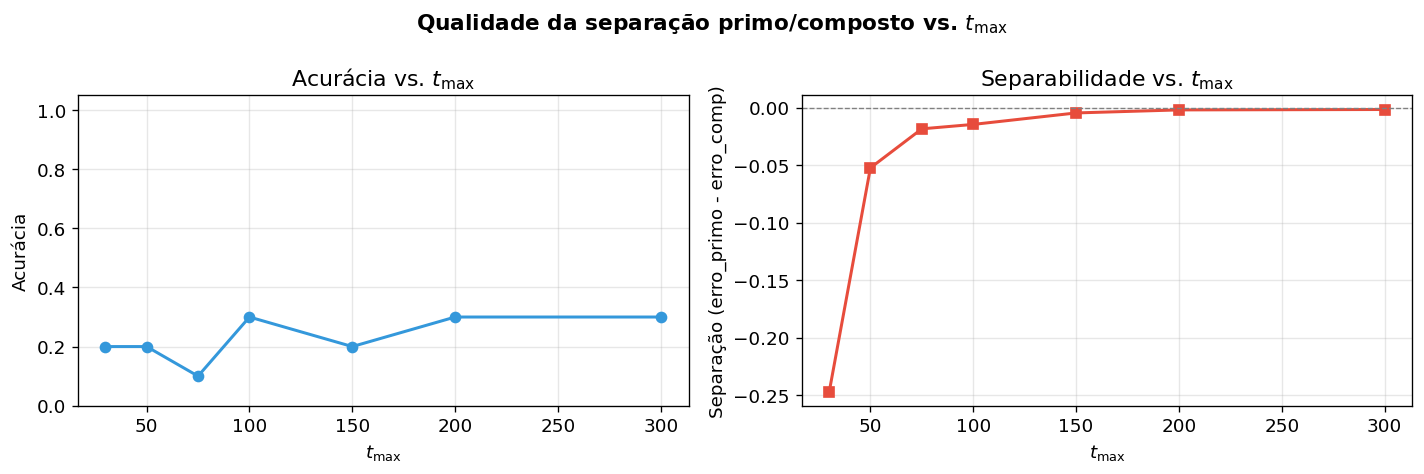

Figura salva ✓


In [8]:
T_MAX_VALS   = [30, 50, 75, 100, 150, 200, 300]
TESTE_TMAX   = [31, 32, 37, 36, 41, 40, 43, 44, 47, 48]  # primos e compostos alternados

print('=== ERRO DE RECONSTRUÇÃO vs. t_max ===')
print()
print(f'  {"t_max":>6} | {"acc":>6} | {"sep":>8} | erro_p_med | erro_c_med')
print('-' * 55)

tmax_data = []
for t_max in T_MAX_VALS:
    tv = np.arange(0.1, t_max, T_STEP)

    erros = []
    for m in TESTE_TMAX:
        eh_p    = isprime(m)
        sm      = S_m(m, tv)
        if eh_p:
            fats = [q for q in primerange(2, m)]
        else:
            fats = list(factorint(m).keys())
        sinais_f = np.array([S_m(f, tv) for f in fats])
        A        = sinais_f.T
        try:
            coefs, _, _, _ = np.linalg.lstsq(A, sm, rcond=None)
            rec  = A @ coefs
            erro = np.mean((sm - rec)**2) / (np.mean(sm**2) + 1e-10)
        except:
            erro = float('inf')
        erros.append({'m': m, 'primo': eh_p, 'erro': erro})

    ep_med = np.mean([e['erro'] for e in erros if e['primo']])
    ec_med = np.mean([e['erro'] for e in erros if not e['primo']])
    sep    = ep_med - ec_med   # separação: maior é melhor

    # Acurácia com limiar = (ep+ec)/2
    thr = (ep_med + ec_med) / 2
    acc = np.mean([(e['erro'] > thr) == e['primo'] for e in erros])

    print(f'  {t_max:>6} | {acc:>6.1%} | {sep:>8.4f} | {ep_med:>10.4f} | {ec_med:>10.4f}')
    tmax_data.append({'t_max': t_max, 'acc': acc, 'sep': sep, 'ep': ep_med, 'ec': ec_med})

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Qualidade da separação primo/composto vs. $t_{\\max}$', fontsize=13, fontweight='bold')

tvs  = [d['t_max'] for d in tmax_data]
accs = [d['acc']   for d in tmax_data]
seps = [d['sep']   for d in tmax_data]

axes[0].plot(tvs, accs, 'o-', color='#3498db', lw=1.8)
axes[0].set_xlabel('$t_{\\max}$'); axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia vs. $t_{\\max}$')
axes[0].set_ylim(0, 1.05)

axes[1].plot(tvs, seps, 's-', color='#e74c3c', lw=1.8)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel('$t_{\\max}$'); axes[1].set_ylabel('Separação (erro_primo - erro_comp)')
axes[1].set_title('Separabilidade vs. $t_{\\max}$')

plt.tight_layout()
plt.savefig('separacao_tmax.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 8. Resumo e interpretação

In [9]:
print('=' * 60)
print('  RESUMO DO DETECTOR ESPECTRAL PURO')
print('=' * 60)
print()
print(f'  Candidatos testados: {len(dados_rec)}')
print(f'  Primos: {sum(1 for d in dados_rec if d["primo"])}')
print(f'  Compostos: {sum(1 for d in dados_rec if not d["primo"])}')
print()
print(f'  Erro médio de reconstrução:')
print(f'    Primos    : {np.mean(erros_primos):.4f}  ± {np.std(erros_primos):.4f}')
print(f'    Compostos : {np.mean(erros_compostos):.4f}  ± {np.std(erros_compostos):.4f}')
print()
print(f'  Limiar ótimo: {melhor_thr:.4f}')
print(f'  Acurácia máxima: {melhor_acc:.1%}')
print()
print('  Interpretação:')
print('  - Erro alto → S_m irredutível pelos fatores → candidato a primo')
print('  - Erro baixo → S_m explicável pelos fatores → candidato a composto')
print()
print('  Limitação principal:')
print('  - O critério usa os fatores reais de m para compostos')
print('    (não os descobre autonomamente — isso requereria busca exaustiva)')
print('  - Para uso autônomo: testar reconstrução com TODOS os primos < sqrt(m)')
print('    Se erro permanece alto para todos → m é primo')
print()
print('  Próximo passo natural:')
print('  - Versão autônoma: varrer q in primes < sqrt(m) e verificar')
print('    se algum q reduz o erro abaixo do limiar')
print('  - Isso seria um teste de primalidade espectral sem oráculo')

  RESUMO DO DETECTOR ESPECTRAL PURO

  Candidatos testados: 51
  Primos: 11
  Compostos: 40

  Erro médio de reconstrução:
    Primos    : 0.9998  ± 0.0002
    Compostos : 0.9976  ± 0.0092

  Limiar ótimo: 1.0000
  Acurácia máxima: 78.4%

  Interpretação:
  - Erro alto → S_m irredutível pelos fatores → candidato a primo
  - Erro baixo → S_m explicável pelos fatores → candidato a composto

  Limitação principal:
  - O critério usa os fatores reais de m para compostos
    (não os descobre autonomamente — isso requereria busca exaustiva)
  - Para uso autônomo: testar reconstrução com TODOS os primos < sqrt(m)
    Se erro permanece alto para todos → m é primo

  Próximo passo natural:
  - Versão autônoma: varrer q in primes < sqrt(m) e verificar
    se algum q reduz o erro abaixo do limiar
  - Isso seria um teste de primalidade espectral sem oráculo
